# 📱 EDA: Влияние соцсетей на психическое здоровье подростков

**Датасет:** Social Media Impact on Teen Mental Health (Kaggle) — 1200 наблюдений  
**Цель:** найти связь между временем в соцсетях и психическим здоровьем подростков  
**Инструменты:** pandas, matplotlib, seaborn  

---

### План работы
1. Загрузка данных
2. Чистка данных
3. Общий портрет выборки
4. Влияние соцсетей на психическое здоровье
5. Корреляции и успеваемость
6. Выводы

## 1. Загрузка данных
Загружаем датасет и смотрим на структуру — типы колонок, размер, первые строки.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
print(df.shape)
print(df.dtypes)
df.head()

(1200, 13)
age                           int64
gender                          str
daily_social_media_hours    float64
platform_usage                  str
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level        str
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## 2. Чистка данных
Проверяем пропуски и дубликаты перед анализом.

In [3]:
print("Пропуски:")
print(df.isnull().sum())
print()
print(f"Дубликаты: {df.duplicated().sum()}")
print()
print(df[['age', 'daily_social_media_hours', 'sleep_hours', 'stress_level', 'anxiety_level', 'addiction_level']].describe())

Пропуски:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Дубликаты: 0

               age  daily_social_media_hours  sleep_hours  stress_level  \
count  1200.000000               1200.000000  1200.000000   1200.000000   
mean     15.928333                  4.536667     6.449417      5.445833   
std       2.021947                  2.029599     1.442677      2.903290   
min      13.000000                  1.000000     4.000000      1.000000   
25%      14.000000                  2.800000     5.200000      3.000000   
50%      16.000000                  4.500000     6.500000      5.000000   
75%      18.000000                  6.300000   

## 3. Общий портрет выборки
Смотрим на распределение по возрасту, полу, платформам и времени в соцсетях.

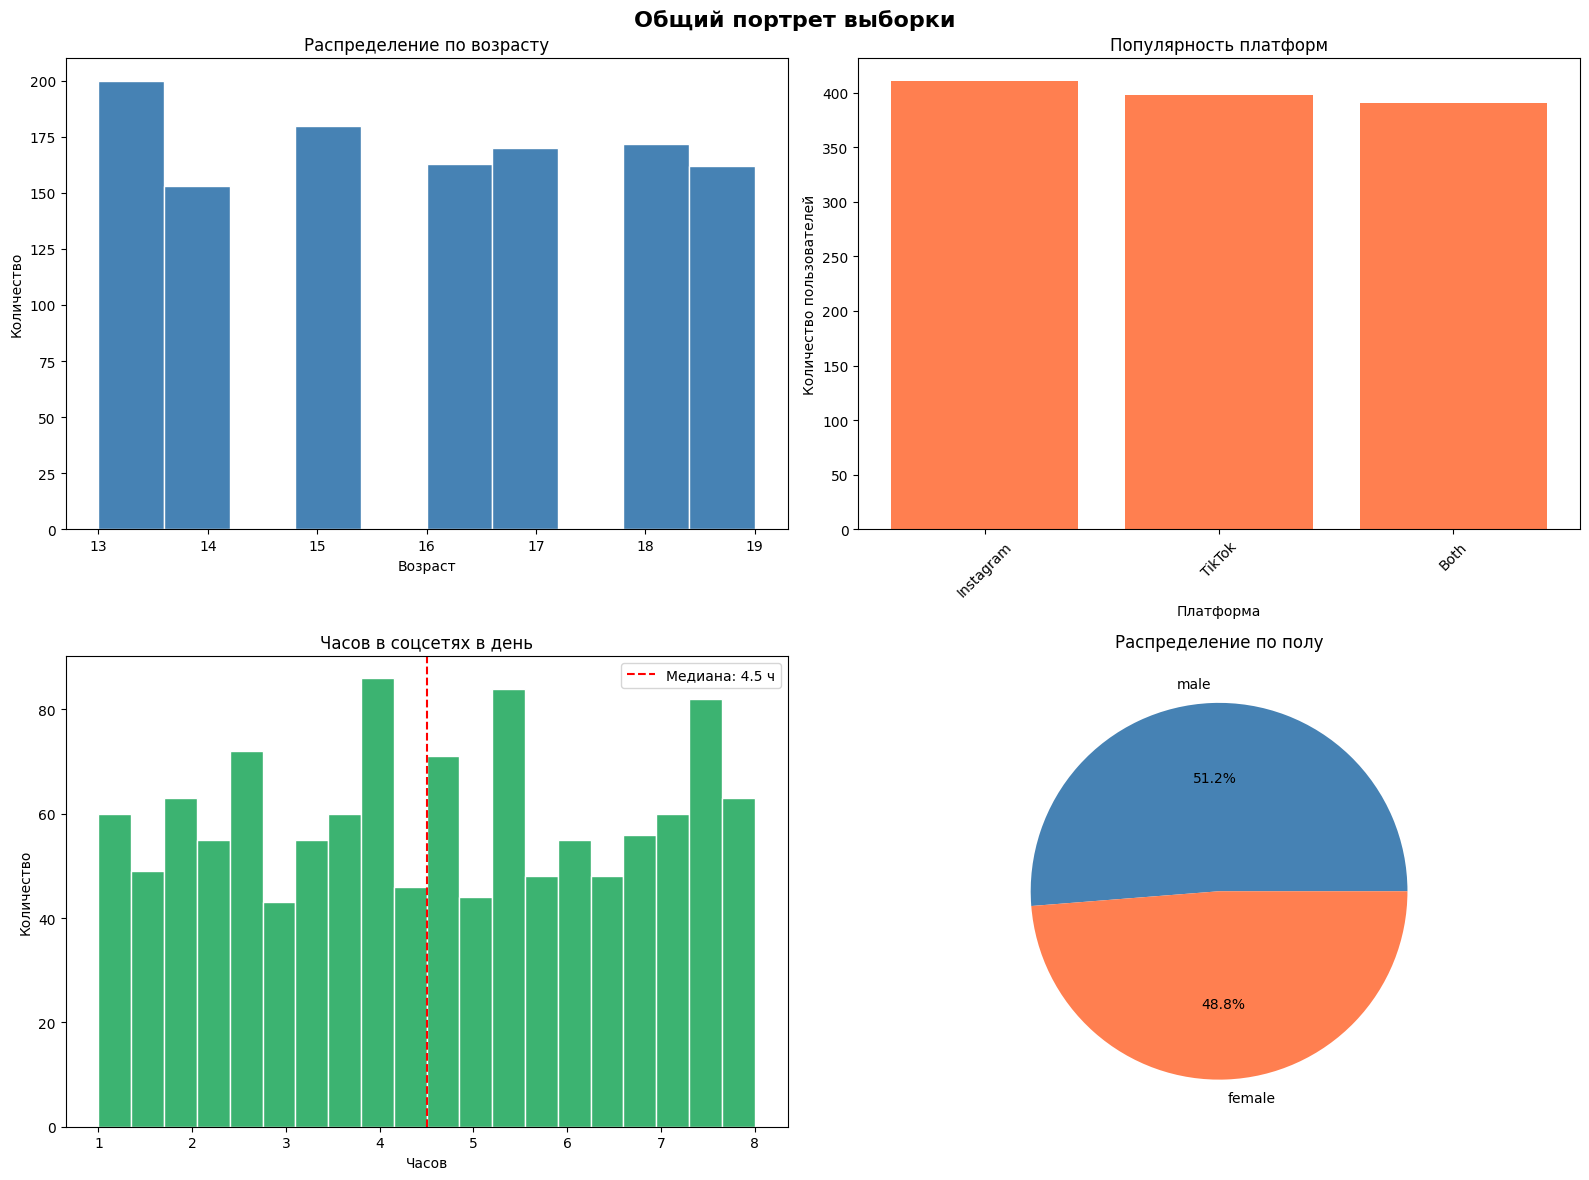

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Общий портрет выборки', fontsize=16, fontweight='bold')

axes[0, 0].hist(df['age'], bins=10, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Распределение по возрасту')
axes[0, 0].set_xlabel('Возраст')
axes[0, 0].set_ylabel('Количество')

platform_counts = df['platform_usage'].value_counts()
axes[0, 1].bar(platform_counts.index, platform_counts.values, color='coral')
axes[0, 1].set_title('Популярность платформ')
axes[0, 1].set_xlabel('Платформа')
axes[0, 1].set_ylabel('Количество пользователей')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].hist(df['daily_social_media_hours'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1, 0].axvline(df['daily_social_media_hours'].median(), color='red', linestyle='--',
                   label=f"Медиана: {df['daily_social_media_hours'].median():.1f} ч")
axes[1, 0].set_title('Часов в соцсетях в день')
axes[1, 0].set_xlabel('Часов')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].legend()

gender_counts = df['gender'].value_counts()
axes[1, 1].pie(gender_counts.values, labels=gender_counts.index,
               autopct='%1.1f%%', colors=['steelblue', 'coral', 'mediumseagreen'])
axes[1, 1].set_title('Распределение по полу')

plt.tight_layout()
plt.show()

## 4. Влияние соцсетей на психическое здоровье
Проверяем гипотезы — связаны ли часы в соцсетях с тревожностью, стрессом и сном.

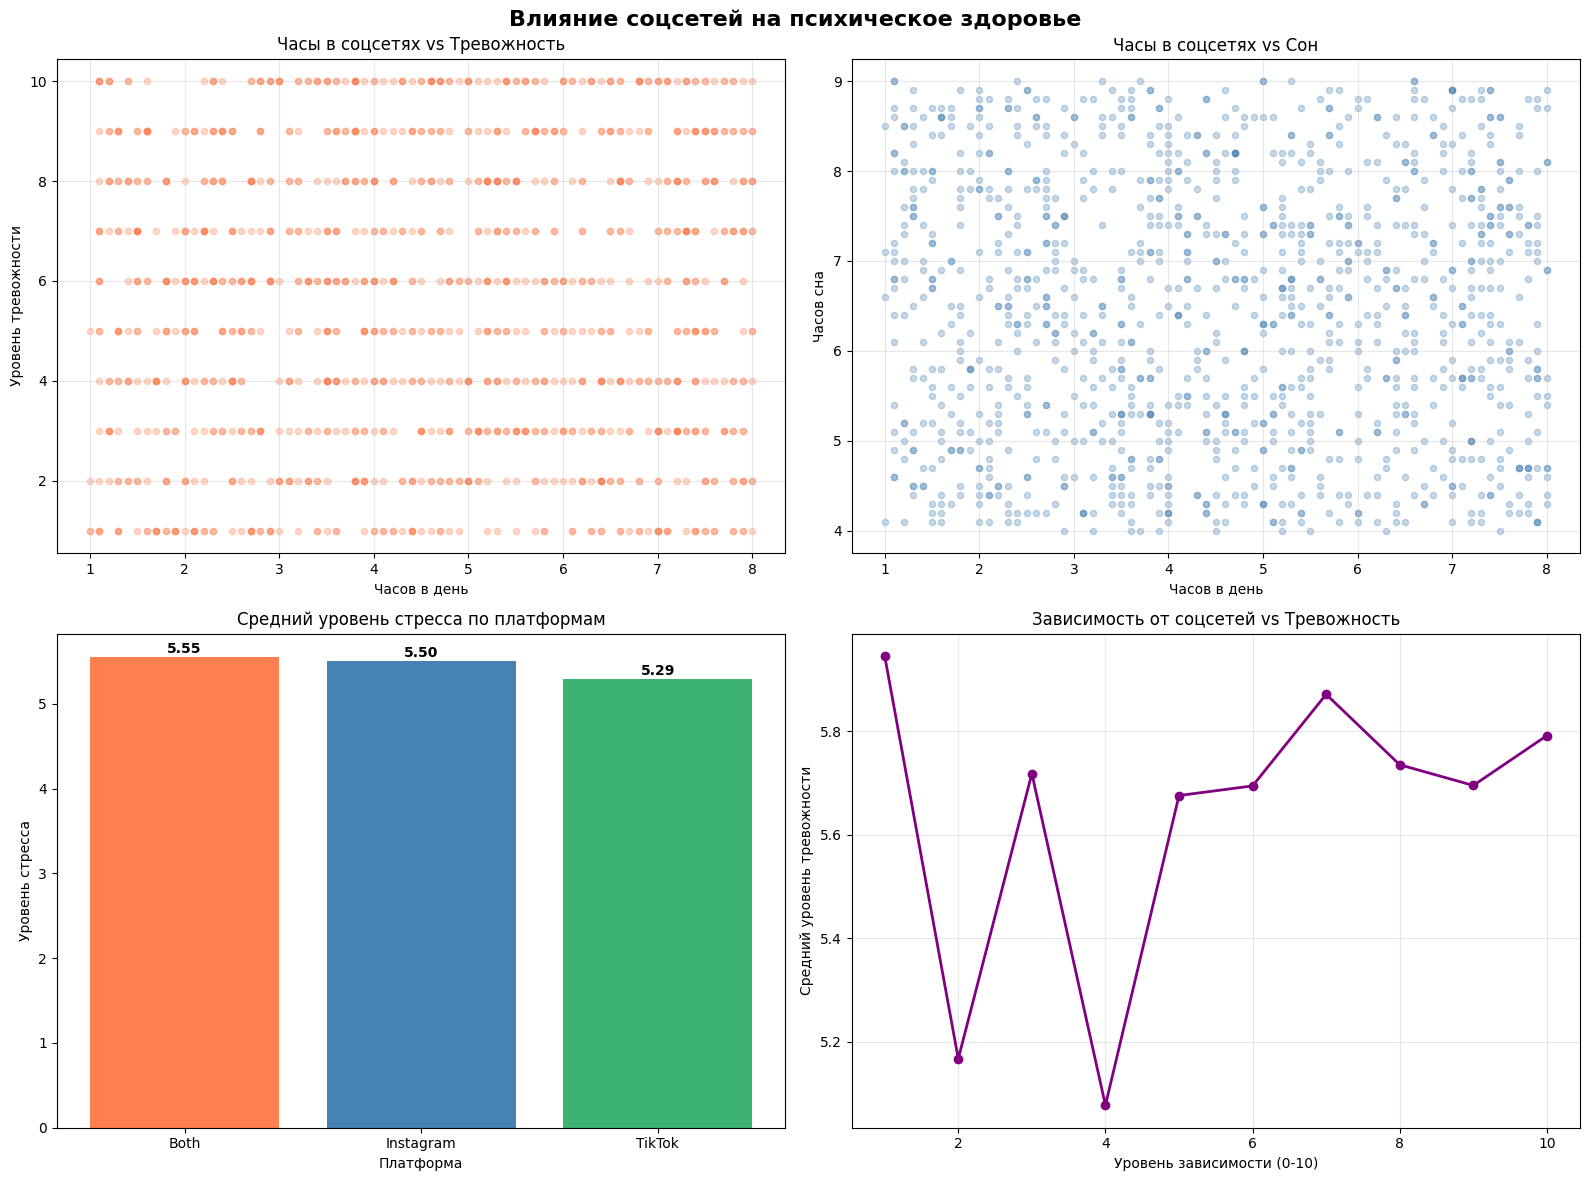

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Влияние соцсетей на психическое здоровье', fontsize=16, fontweight='bold')


axes[0, 0].scatter(df['daily_social_media_hours'], df['anxiety_level'],
                   alpha=0.3, color='coral', s=20)
axes[0, 0].set_title('Часы в соцсетях vs Тревожность')
axes[0, 0].set_xlabel('Часов в день')
axes[0, 0].set_ylabel('Уровень тревожности')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(df['daily_social_media_hours'], df['sleep_hours'],
                   alpha=0.3, color='steelblue', s=20)
axes[0, 1].set_title('Часы в соцсетях vs Сон')
axes[0, 1].set_xlabel('Часов в день')
axes[0, 1].set_ylabel('Часов сна')
axes[0, 1].grid(True, alpha=0.3)

stress_by_platform = df.groupby('platform_usage')['stress_level'].mean().sort_values(ascending=False)
axes[1, 0].bar(stress_by_platform.index, stress_by_platform.values,
               color=['coral', 'steelblue', 'mediumseagreen'])
axes[1, 0].set_title('Средний уровень стресса по платформам')
axes[1, 0].set_xlabel('Платформа')
axes[1, 0].set_ylabel('Уровень стресса')
for i, v in enumerate(stress_by_platform.values):
    axes[1, 0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

depression_by_addiction = df.groupby('addiction_level')['anxiety_level'].mean()
axes[1, 1].plot(depression_by_addiction.index, depression_by_addiction.values,
                color='purple', linewidth=2, marker='o')
axes[1, 1].set_title('Зависимость от соцсетей vs Тревожность')
axes[1, 1].set_xlabel('Уровень зависимости (0-10)')
axes[1, 1].set_ylabel('Средний уровень тревожности')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Корреляции и успеваемость
Тепловая карта корреляций между всеми числовыми признаками.
Проверяем влияет ли зависимость от соцсетей на академическую успеваемость.

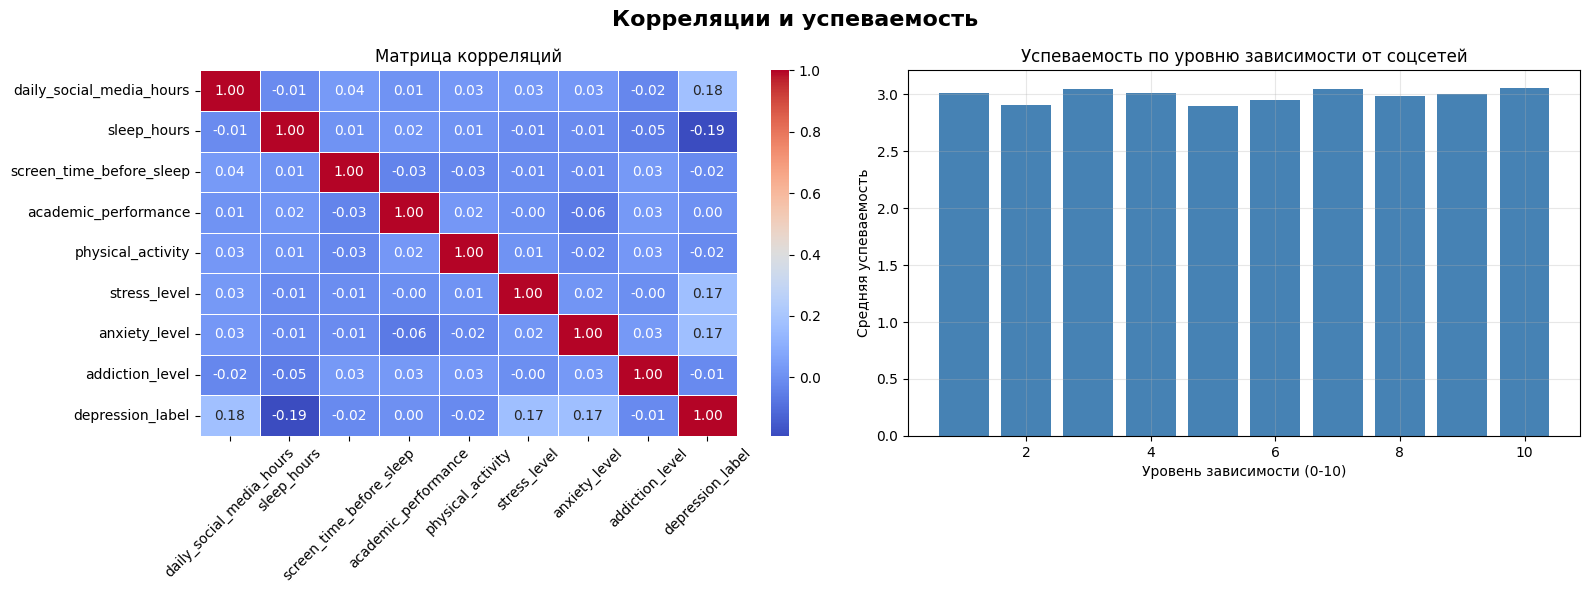

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Корреляции и успеваемость', fontsize=16, fontweight='bold')

corr_cols = ['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
             'academic_performance', 'physical_activity', 'stress_level',
             'anxiety_level', 'addiction_level', 'depression_label']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Матрица корреляций')
axes[0].tick_params(axis='x', rotation=45)

academic_by_addiction = df.groupby('addiction_level')['academic_performance'].mean()
axes[1].bar(academic_by_addiction.index, academic_by_addiction.values,
            color='steelblue')
axes[1].set_title('Успеваемость по уровню зависимости от соцсетей')
axes[1].set_xlabel('Уровень зависимости (0-10)')
axes[1].set_ylabel('Средняя успеваемость')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Выводы по проекту

### Датасет
- 1200 подростков, возраст 13–19 лет, данные за 2025 год
- Выборка сбалансированная: 51.2% мальчики, 48.8% девочки
- Платформы распределены равномерно: Instagram, TikTok, Both

### Ключевые инсайты

**1. Медиана времени в соцсетях — 4.5 часа в день**
Это выше рекомендованной нормы для подростков (1-2 часа).

**2. Прямой связи между временем в соцсетях и тревожностью нет**
Корреляция daily_social_media_hours и anxiety_level = 0.03 — почти ноль.
Время в соцсетях само по себе не предсказывает уровень тревоги.

**3. Сон слабо связан с депрессией**
Корреляция sleep_hours и depression_label = -0.19 — чем меньше сна, тем выше риск депрессии.
Единственная заметная связь в данных.

**4. Платформы одинаково влияют на стресс**
Both — 5.55, Instagram — 5.50, TikTok — 5.29. Разница минимальная.

**5. Уровень зависимости не влияет на успеваемость**
График успеваемости по уровню зависимости — почти прямая линия ~3.0.
Академическая успеваемость не страдает от зависимости от соцсетей в этих данных.

### Общий вывод
Данные синтетические — корреляции между признаками близки к нулю.
В реальных данных связи были бы сильнее. Тем не менее проект показывает
полный цикл EDA: загрузка → чистка → визуализация → выводы.
